<a href="https://colab.research.google.com/github/Jsspreet-kaur/Movie-Recommendation-System/blob/main/imageclassification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import cv2
import numpy as np
import urllib.request
import matplotlib.pyplot as plt
from keras.datasets import cifar10
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.utils import to_categorical
from keras.models import Sequential
from keras.layers import Dense, Conv2D, MaxPooling2D
from keras.layers import Dropout, Flatten, BatchNormalization
from keras.regularizers import l2
from keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping



In [ ]:
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

In [ ]:
train_test_split

<function sklearn.model_selection._split.train_test_split(*arrays, test_size=None, train_size=None, random_state=None, shuffle=True, stratify=None)>

In [ ]:
print(X_train.shape)

(50000, 32, 32, 3)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_valid, y_train, y_validation = train_test_split(X_train,y_train, test_size=0.1, random_state=101 )

In [ ]:
X_train.shape, y_train.shape

((45000, 32, 32, 3), (45000, 1))

In [ ]:
y_train

array([[9],
       [7],
       [8],
       ...,
       [2],
       [5],
       [0]], dtype=uint8)

In [ ]:
X_valid.shape

(5000, 32, 32, 3)

In [ ]:
y_validation.shape

(5000, 1)

In [ ]:
X_test.shape, y_test.shape

((10000, 32, 32, 3), (10000, 1))

In [ ]:
class_names = [
              'airplane',
             'automobile',
             'bird',
             'cat',
             'deer',
             'dog',
             'frog',
             'horse',
             'ship',
             'truck'
             ]

In [ ]:
from keras.datasets import cifar10
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

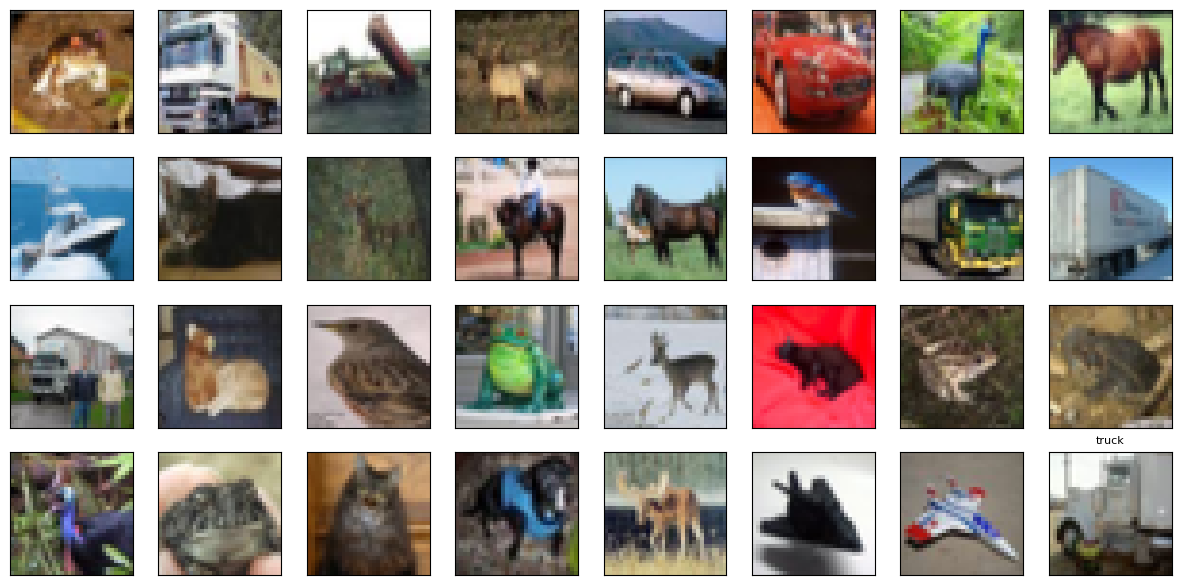

In [ ]:
plt.figure(figsize=(15,15))
for i in range(32):
  plt.subplot(8,8,i+1)
  plt.xticks([])
  plt.yticks([])
  plt.grid(False)
  plt.imshow(X_train[i])
plt.title(class_names[y_train[i] [0]], fontsize=8)

plt.show()



In [ ]:
X_train = X_train.astype('float32')
X_test = X_test.astype('float32')
X_valid = X_valid.astype('float32')

mean = np.mean(X_train)
std = np.std(X_train)

X_train = (X_train-mean)/(std+.00000001)
X_test = (X_test-mean)/(std+.00000001)
X_valid = (X_valid-mean)/(std+.00000001)

In [ ]:
y_train = to_categorical(y_train,10)
y_test = to_categorical(y_test,10)
y_validation = to_categorical(y_validation,10)

In [ ]:
data_generator = ImageDataGenerator(
    rotation_range = 15,
    width_shift_range = .12,
    height_shift_range = 0.12,
    horizontal_flip =True,
    zoom_range = 0.1,
    brightness_range = [0.9,1.1],
    shear_range = 10,
    channel_shift_range = 0.1
)

In [ ]:
model = Sequential()

weight_decay = 0.0001

model.add(Conv2D(filters=32,
                 kernel_size = (3,3),
                 padding='same',
                 activation = 'relu',
                 input_shape=(32,32,3),
                 kernel_regularizer = l2(weight_decay)))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout( rate=0.2))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 896 (3.50 KB)

 Trainable params: 896 (3.50 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model = Sequential()

weight_decay = 0.0001

model.add(Conv2D(filters=128,
                 kernel_size = (3,3),
                 padding='same',
                 activation = 'relu',
                 input_shape=(32,32,3),
                 kernel_regularizer = l2(weight_decay)))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout( rate=0.3))

In [ ]:
model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 128)    │         3,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16, 16, 128)    │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,584 (14.00 KB)

 Trainable params: 3,584 (14.00 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model = Sequential()

weight_decay = 0.0001

model.add(Conv2D(filters=256,
                 kernel_size = (3,3),
                 padding='same',
                 activation = 'relu',
                 input_shape=(32,32,3),
                 kernel_regularizer = l2(weight_decay)))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout( rate=0.4))

model.add(Flatten())
model.add(Dense(10, activation = 'softmax'))

In [ ]:
print(X_train.shape)
print(X_valid.shape)
print(y_train.shape)


(50000, 32, 32, 3)
(5000, 32, 32, 3)
(50000, 10)


In [ ]:
batch_size =64
epochs =25

optimizer = Adam(learning_rate=0.0005)

model.compile(
    optimizer = optimizer,
    loss = 'categorical_crossentropy',
    metrics = ['accuracy']
    )

reduce_lr = ReduceLROnPlateau(
    monitor = 'val_loss',
    factor =0.5,
    patience = 10,
    min_lr = .00001
    )




In [ ]:
early_stopping = EarlyStopping(
    monitor = 'val_loss',
    patience = 40,
    restore_best_weights=True,
    verbose=1
    )


In [ ]:
history = model.fit (
    data_generator.flow(
        X_train,
        y_train,
        batch_size=batch_size
    ),
    epochs = epochs,
    validation_data = (X_valid, y_validation),
    callbacks = [reduce_lr, early_stopping],
    verbose=2
)

Epoch 1/25
782/782 - 194s - 248ms/step - accuracy: 0.4502 - loss: 1.5573 - val_accuracy: 0.5380 - val_loss: 1.3489 - learning_rate: 5.0000e-04
Epoch 2/25
782/782 - 177s - 226ms/step - accuracy: 0.5268 - loss: 1.3536 - val_accuracy: 0.5762 - val_loss: 1.2624 - learning_rate: 5.0000e-04
Epoch 3/25
782/782 - 175s - 224ms/step - accuracy: 0.5539 - loss: 1.2780 - val_accuracy: 0.6046 - val_loss: 1.1814 - learning_rate: 5.0000e-04
Epoch 4/25
782/782 - 182s - 233ms/step - accuracy: 0.5705 - loss: 1.2410 - val_accuracy: 0.6060 - val_loss: 1.1764 - learning_rate: 5.0000e-04
Epoch 5/25
782/782 - 174s - 223ms/step - accuracy: 0.5775 - loss: 1.2204 - val_accuracy: 0.6078 - val_loss: 1.1881 - learning_rate: 5.0000e-04
Epoch 6/25
782/782 - 175s - 224ms/step - accuracy: 0.5865 - loss: 1.1959 - val_accuracy: 0.6290 - val_loss: 1.1288 - learning_rate: 5.0000e-04
Epoch 7/25
782/782 - 175s - 224ms/step - accuracy: 0.5939 - loss: 1.1783 - val_accuracy: 0.6358 - val_loss: 1.0944 - learning_rate: 5.0000e-04

In [ ]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 256)    │         7,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 65536)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │       655,370 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,987,616 (7.58 MB)

 Trainable params: 662,538 (2.53 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,325,078 (5.05 MB)

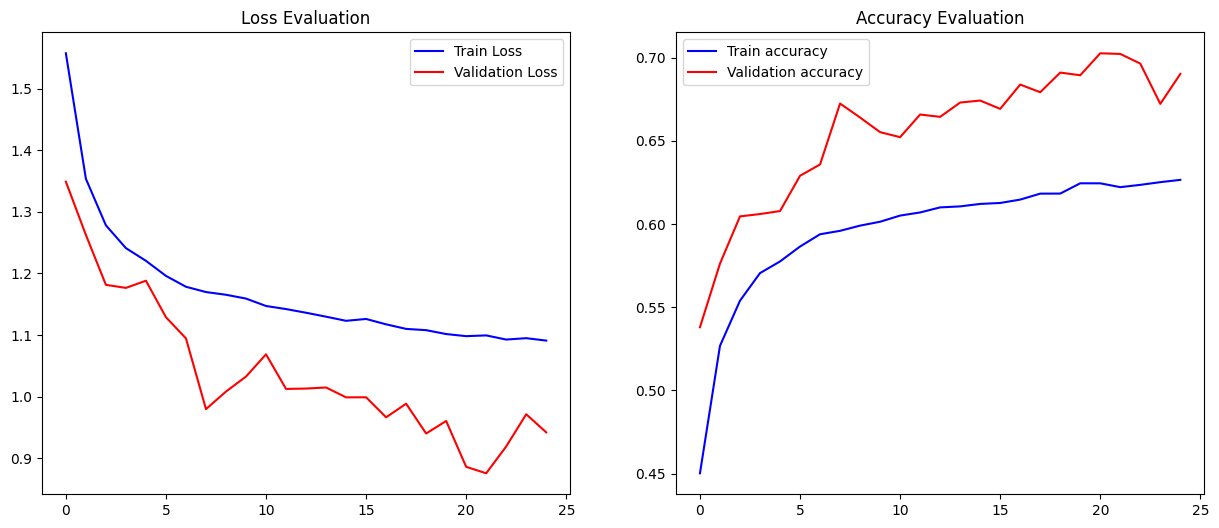

In [ ]:
plt.figure(figsize=(15,6))

plt.subplot(1,2,1)
plt.plot(model.history.history['loss'], label = 'Train Loss', color = 'blue')
plt.plot(model.history.history['val_loss'], label = 'Validation Loss', color = 'red')
plt.legend()
plt.title('Loss Evaluation')

plt.subplot(1,2,2)
plt.plot(model.history.history['accuracy'], label = 'Train accuracy', color = 'blue')
plt.plot(model.history.history['val_accuracy'], label = 'Validation accuracy', color = 'red')
plt.legend()
plt.title('Accuracy Evaluation')

plt.show()


In [ ]:
test_loss, test_acc = model.evaluate(X_test,y_test, verbose = 1)

print(f"Test Accuracy : {test_acc}\nTestLoss: {test_loss}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 24ms/step - accuracy: 0.6809 - loss: 0.9708
Test Accuracy : 0.680899977684021
TestLoss: 0.9708455801010132


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving horse.jpg to horse.jpg


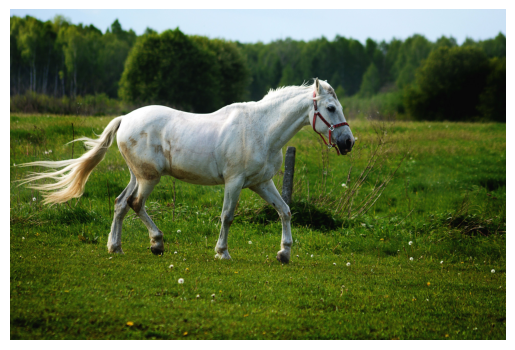

In [ ]:
import cv2
import matplotlib.pyplot as plt

image = cv2.imread("horse.jpg")
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.imshow(image)
plt.axis("off")
plt.show()

In [ ]:
image.shape

(2712, 4065, 3)

In [ ]:
image = cv2.resize(image, (32, 32))

# normalize the image
image = (image - mean) / (std + 0.000001)

# Add an extra dimension because the model expects a batch of images
image = image.reshape((1, 32, 32, 3))

In [ ]:
predict = model.predict(image)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step


In [ ]:
predict

array([[3.72497350e-01, 4.02888209e-01, 8.21867958e-02, 2.11226862e-07,
        1.31622702e-02, 1.62902495e-07, 1.21464215e-01, 7.01501174e-03,
        9.13611166e-06, 7.76571338e-04]], dtype=float32)

In [ ]:
predict.argmax()

np.int64(1)